# -----------------------------------------------
# 📈 Hopify Churn: Quarterly Churn Line Chart
# -----------------------------------------------

In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

# ================================
# 📁 Set Base Path to Project Root
# ================================

In [ ]:
# ================================
# 📁 Set Base Path to Project Root
# ================================

import os
import pandas as pd  # Don't forget to import this if not already

try:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..", ".."))
except NameError:
    # Jupyter or interactive context
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))

print("📁 Base path set to:", BASE_PATH)


# ================================
# 📥 Load Churn Data from CSV
# ================================

In [16]:
file_path = os.path.join(
    BASE_PATH,
    "01_project_artifacts",
    "02_sql_output",
    "01_project_churn_retention_analysis",
    "03_monthly_churn_rate_seg_target.csv"
)

churn_df = pd.read_csv(file_path)

# ================================
# 🔄 Format Data
# ================================

In [17]:
churn_df['Month'] = pd.to_datetime(churn_df['Month'], format='%Y-%m')
churn_df['QuarterLabel'] = churn_df['Month'].dt.to_period('Q').astype(str)
churn_df = churn_df.sort_values('Month')

segments = ['Enterprise', 'Mid-Market', 'SMB']
palette = {
    'Enterprise': '#1f77b4',
    'Mid-Market': '#ff7f0e',
    'SMB': '#9f13ef'
}

# ================================
# 📈 Plot: Quarterly Churn Line Chart with Benchmarks
# ================================

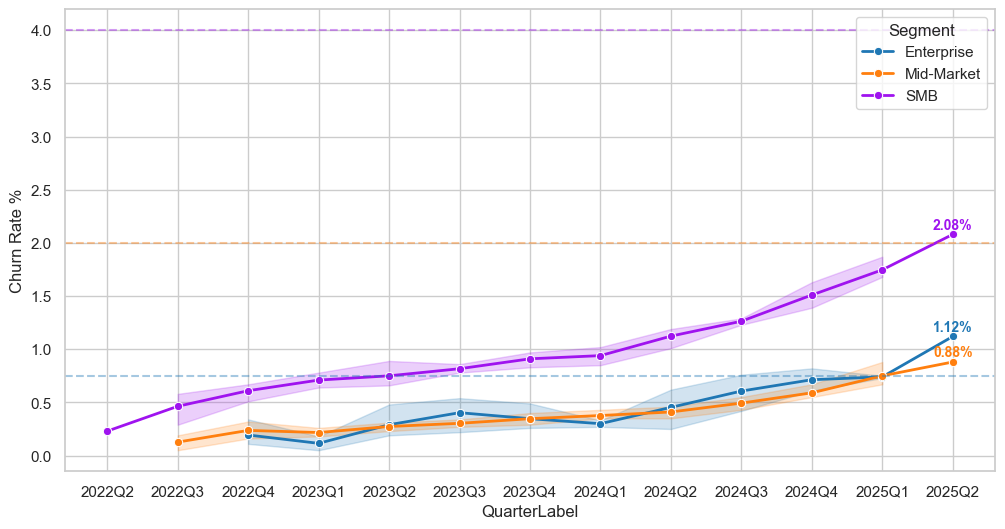

In [18]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=churn_df,
    x="QuarterLabel",
    y="Churn Rate %",
    hue="Segment",
    hue_order=segments,
    palette=palette,
    marker="o",
    linewidth=2
)

# Add benchmark lines (no fill)
for segment in segments:
    seg_df = churn_df[churn_df['Segment'] == segment]
    if not seg_df.empty:
        benchmark = seg_df['Benchmark Churn Rate %'].iloc[0]
        plt.axhline(
            y=benchmark,
            linestyle='--',
            color=palette[segment],
            alpha=0.4,
            label=f"{segment} Benchmark ({benchmark:.2f}%)"
        )

# Annotate latest data points
latest_points = churn_df.sort_values('Month').groupby('Segment').tail(1)
for _, row in latest_points.iterrows():
    plt.text(
        row['QuarterLabel'],
        row['Churn Rate %'] + 0.05,
        f"{row['Churn Rate %']:.2f}%",
        color=palette[row['Segment']],
        weight='bold',
        fontsize=10,
        ha='center'
    )